##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [2]:
import tensorflow as tf
import keras_cv
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

In [3]:
model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

In [4]:
image_urls = [
    "https://images.unsplash.com/photo-1459603677915-a62079ffd002?q=80&w=1234&auto=format&fit=crop",  # car
    "https://images.unsplash.com/photo-1698936061086-2bf99c7b9fc5?q=80&w=1074&auto=format&fit=crop",  # sofa
    "https://images.unsplash.com/photo-1474487548417-781cb71495f3?q=80&w=1284&auto=format&fit=crop",  # train
    "https://images.unsplash.com/photo-1561037404-61cd46aa615b?q=80&w=1170&auto=format&fit=crop",  # dog
    "https://images.unsplash.com/photo-1596854407944-bf87f6fdd49e?q=80&w=880&auto=format&fit=crop"   # cat
]

In [5]:
def load_image_from_url(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    return np.array(img)

images = [load_image_from_url(url) for url in image_urls]

In [6]:
inference_resizing = keras_cv.layers.Resizing(
    640,
    640,
    pad_to_aspect_ratio=True,
    bounding_box_format="xywh"
)

resized_images = []

for img in images:
    resized = inference_resizing(
        {
            "images": tf.expand_dims(img, axis=0),
            "bounding_boxes": {
                "boxes": tf.zeros((1,0,4)),
                "classes": tf.zeros((1,0))
            }
        }
    )["images"]
    
    resized_images.append(resized[0])

resized_images = tf.stack(resized_images)

In [7]:
predictions = model.predict(resized_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step


In [8]:
class_names = [
    "aeroplane","bicycle","bird","boat","bottle","bus","car","cat",
    "chair","cow","diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor"
]

In [9]:
def visualize_detections(image, boxes, classes, scores, threshold=0.4):
    
    plt.figure(figsize=(6,6))
    plt.imshow(image.astype("uint8"))
    ax = plt.gca()
    
    for box, cls, score in zip(boxes, classes, scores):
        
        if score < threshold:
            continue
            
        x, y, w, h = box
        
        rect = plt.Rectangle(
            (x, y),
            w,
            h,
            fill=False,
            linewidth=2
        )
        
        ax.add_patch(rect)
        
        label = f"{class_names[int(cls)]}: {score:.2f}"
        
        ax.text(
            x,
            y,
            label,
            bbox=dict(facecolor='white', alpha=0.8)
        )
    
    plt.axis("off")
    plt.show()

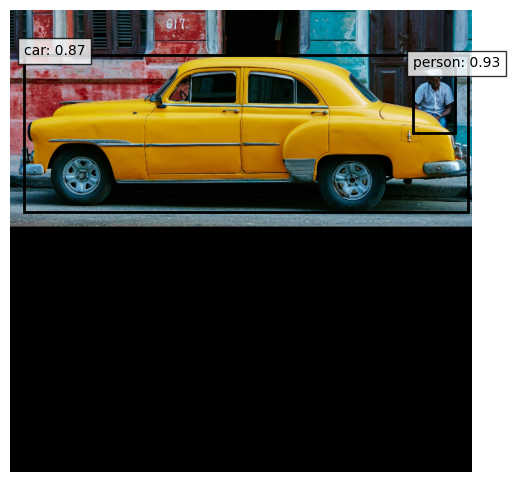

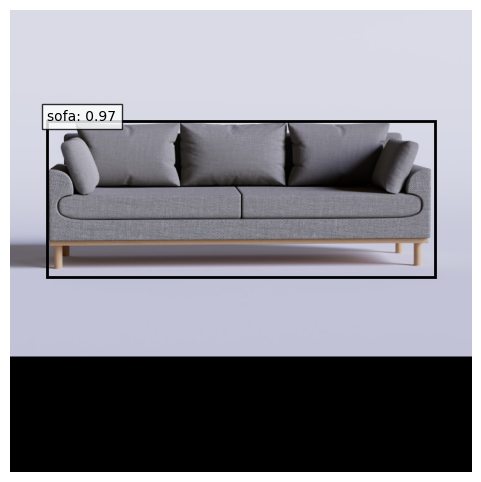

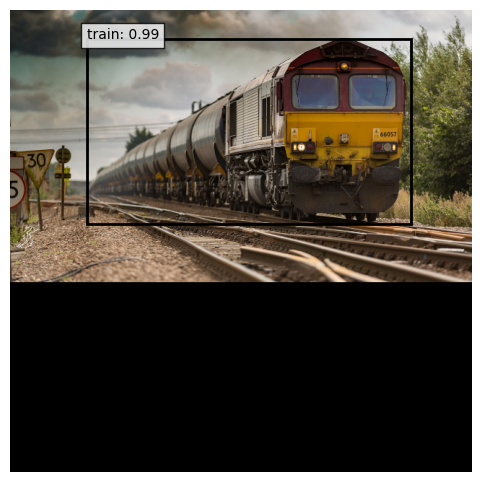

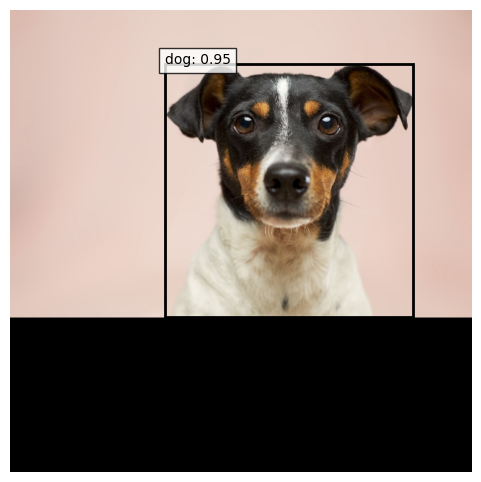

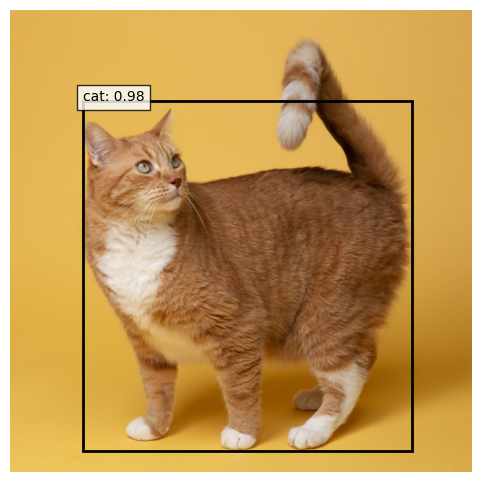

In [10]:
for i in range(len(images)):
    
    boxes = predictions["boxes"][i]
    classes = predictions["classes"][i]
    scores = predictions["confidence"][i]
    
    visualize_detections(
        resized_images[i].numpy(),
        boxes,
        classes,
        scores
    )

In [13]:
for i in range(len(images)):

    print(f"\nImage {i+1}")

    boxes = predictions["boxes"][i]
    classes = predictions["classes"][i]
    scores = predictions["confidence"][i]
    num_detections = int(predictions["num_detections"][i])

    for j in range(num_detections):

        label = class_names[int(classes[j])]
        confidence = scores[j]

        if confidence > 0.3:
            print(f"Detected: {label} | Confidence: {confidence:.2f}")


Image 1
Detected: person | Confidence: 0.93
Detected: car | Confidence: 0.87

Image 2
Detected: sofa | Confidence: 0.97

Image 3
Detected: train | Confidence: 0.99

Image 4
Detected: dog | Confidence: 0.95

Image 5
Detected: cat | Confidence: 0.98


| Image   | True Object | Detected Object | Confidence Score | Correct Detection | Missed Objects |
| ------- | ----------- | --------------- | ---------------- | ----------------- | -------------- |
| Image 1 | Car         | Car             | 0.87             | Yes               | None           |
| Image 1 | Person      | Person          | 0.93             | Yes               | None           |
| Image 2 | Sofa        | Sofa            | 0.97             | Yes               | None           |
| Image 3 | Train       | Train           | 0.99             | Yes               | None           |
| Image 4 | Dog         | Dog             | 0.95             | Yes               | None           |
| Image 5 | Cat         | Cat             | 0.98             | Yes               | None           |
